# 01 - Meteogram quicklook: NW & NF

Time–height pcolormesh of bulk droplet (NW) and ice-crystal (NF) number
concentrations for every meteogram station in the Zarr store.

Layout: **n_stations rows x 2 columns** (left = NW, right = NF).

### Zarr v2 / v3 compatibility notes

The Zarr stores are written with `zarr_format=2` to work around several
incompatibilities between `xarray` (≥ 2025.4) and `zarr-python` 3.x:

| Issue | Symptom | Resolution |
|-------|---------|------------|
| **Codec API mismatch** | `TypeError: Expected a BytesBytesCodec. Got <class 'numcodecs.blosc.Blosc'>` | Force `zarr_format=2` in `to_zarr()` so `numcodecs.Blosc` is accepted as `compressor`. |
| **Unicode string dtype** | `ValueError: No Zarr data type found that matches {'name': '<U14', 'object_codec_id': 'vlen-utf8'}` | Store string coordinates (e.g. `expname`) as fixed-length bytes (`dtype='S'`) instead of Unicode (`dtype='U'`). zarr-python 3.x infers a `vlen-utf8` codec for `<U` arrays but cannot read it back. |
| **Region writes on coords** | `ValueError: variables … must have at least one dimension in common with the region's dimensions` | Abandoned streaming region-writes; build the full dataset lazily, then write in a single pass. |
| **Fill-value round-trip** | `AttributeError: 'Float32' object has no attribute 'value'` on `open_dataset` | Caused by zarr v3 metadata on read; pinning `zarr_format=2` avoids the issue. |

Existing stores created with `<U` dtypes can be patched locally by converting
the `expname` chunk data from `<U14` → `|S14` and updating `.zarray` /
`.zmetadata` (see `docs/logbook.md`, entry 2026-03-04).

In [24]:
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server
import platform, socket
print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: MacBookPro
is_server: False


In [25]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from utilities.plotting import get_extpar_data, create_new_jet3, create_fade_cmap, make_pastel

## Configuration

In [26]:
zarr_file = "Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr"
cs_run = "_".join(zarr_file.split("_")[1:5])

if is_server():
    root = Path("/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x40x100")
    data_dir = root / "ensemble_output" / cs_run
    extpar_path = root / "COS_in" / "extPar_Eriswil_50x40.nc"
else:
    data_dir = Path.home() / "data" / "cosmo-specs" / "meteograms" / cs_run
    extpar_path = Path.home() / "data" / "cosmo-specs" / "meteograms" / "extPar_Eriswil_50x40.nc"

# zarr_files = sorted(data_dir.glob(data_dir))
zarr_files = [data_dir / zarr_file]
print(f"Available Zarr stores in {data_dir}:")
for z in zarr_files:
    print(f"  {z.name}")

# pick the store to plot (edit index or path as needed)
zarr_path = zarr_files[-1]
print(f"\nUsing: {zarr_path.name}")
print(f"ExtPar: {extpar_path.name}")

Available Zarr stores in /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254:
  Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr

Using: Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr
ExtPar: extPar_Eriswil_50x40.nc


In [27]:
LBB = slice(30, 50)   # liquid bin range
CBB = slice(30, 50)   # crystal bin range

# experiment index to plot
EXP_IDX = 0

# (output_name, source_var, bin_slice, pos_filter, plot_label, norm_kwargs)
var_config = [
    ("NW_bulk",       "NW",            LBB, True,  "NW – droplet",           dict(vmin=1, vmax=600)),
    ("NF_bulk",       "NF",            CBB, True,  "NF – ice crystal",       dict(norm=mcolors.LogNorm(vmin=1e-3, vmax=10))),
    ("SUM_CONDN",     "SUM_CONDN",     LBB, False, "CONDN – condensation",   dict(norm=mcolors.SymLogNorm(linthresh=1e-4, linscale=0.01))),
    ("SUM_KOLLNI",    "SUM_KOLLNI",    CBB, False, "KOLLNI – collision",     dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01))),
    ("SUM_IMMERN",    "SUM_IMMERN",    CBB, False, "IMMERN – immersion frz", dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01))),
    ("SUM_KOLLNFROD", "SUM_KOLLNFROD", CBB, False, "KOLLNFROD – coll-coal",  dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01))),
]

# only keep variables that actually exist in the zarr store (auto-filter)
# (evaluated after ds is loaded, see next section)

## Load data

In [28]:
ds = xr.open_dataset(zarr_path, engine="zarr")
print("Sizes:", dict(ds.sizes))
print("Data vars:", list(ds.data_vars))

assert "NW" in ds.data_vars and "NF" in ds.data_vars, (
    f"Zarr store must contain NW and NF. Found: {list(ds.data_vars)}"
)

Sizes: {'expname': 5, 'station': 3, 'time': 4033, 'height_level': 20, 'bins': 66, 'height_level2': 21, 'bins_boundaries': 67}
Data vars: ['SUM_CONDNFROD', 'SUM_P_kollqwf', 'SUM_P_BREAN', 'SUM_P_dqfmelt', 'PML', 'SUM_N_deponf', 'SUM_HOMN', 'SUM_kqf', 'NW', 'QV', 'SUM_P_KOLLQFROD', 'SUM_IMMERN', 'SUM_P_dqwmelt', 'SUM_dqfwmelt', 'SUM_N_IMMERN', 'SUM_CONDQWFROD', 'SUM_P_dnfmelt', 'SUM_N_KOLLQFROD_INS', 'SUM_dnwmelt', 'NINP', 'QFS', 'SUM_depoqf', 'SUM_P_deponf', 'SUM_N_kollqwf', 'SUM_N_CONDQFROD', 'QF', 'SUM_CONDQFROD', 'QIA', 'SUM_N_dqfwmelt', 'SUM_N_KOLLNFROD', 'SUM_P_KOLLNFROD_INS', 'SUM_P_KOLLNI', 'SUM_P_CONDQFROD', 'RHO', 'RGRENZ_right', 'SUM_P_KOLLQFROD_INS', 'SUM_dnfmelt', 'SUM_N_KOLLQFROD', 'SUM_CONDN', 'SUM_KOLLNFROD', 'SUM_N_dqffrier', 'PHL', 'SUM_P_dqfwmelt', 'SUM_N_CONDNFROD', 'QWS', 'SUM_P_HOMQ', 'QFA', 'SUM_P_dqffrier', 'SUM_N_KOLLQI', 'SUM_P_kqf', 'SUM_N_HOMN', 'SUM_BREAQ', 'SUM_N_kqwf', 'SUM_N_BREAN', 'SUM_N_KOLLNFRODI', 'SUM_N_CONDN', 'SUM_deponf', 'SUM_kollqwf', 'SUM_P_KOL

In [ ]:
new_jet3 = create_new_jet3()
new_jet3_soft = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)


Spectral variables: 


In [76]:

# keep only variables that exist
spectral_vars = [v for v in ds.data_vars]
print(f"Spectral variables: ")
net, pos, neg, rest = [], [], [], []
for v in sorted(spectral_vars):
    if "SUM_P_" in v:
        pos.append(v)
    elif "SUM_N_" in v:
        neg.append(v)
    elif "SUM_" in v:
        net.append(v)
    else:
        rest.append(v)

# Sum over all dimensions except 'time'

ds_tend_net_t = ds[net].mean(dim=['expname']).sum(dim=['bins','height_level', 'station']).load()
ds_tend_pos_t = ds[pos].mean(dim=['expname']).sum(dim=['bins','height_level', 'station']).load()
ds_tend_neg_t = ds[neg].mean(dim=['expname']).sum(dim=['bins','height_level', 'station']).load()
ds_sum_net = ds_tend_net_t.sum()

ds_flux_net_t = ds[net].diff(dim='time').mean(dim=['expname']).sum(dim=['bins','height_level', 'station']).load()
ds_flux_pos_t = ds[pos].diff(dim='time').mean(dim=['expname']).sum(dim=['bins','height_level', 'station']).load()
ds_flux_neg_t = ds[neg].diff(dim='time').mean(dim=['expname']).sum(dim=['bins','height_level', 'station']).load()
ds_flux_sum_net = ds_flux_net_t.sum()



Spectral variables: 


In [ ]:
# print tendencies
header = f"           varnames:     net_tend        net_flux           pos_tend      pos_flux             neg_tend      neg_flux"
print(header)
print(f"{'-' * (len(header)+4)}")
for vnt, vpo, vne in zip(net, pos, neg):
    if np.abs(ds_sum_net[vnt]) > 1e-16:
        net_tend = f"{vnt:>20}  {ds_tend_net_t[vnt].sum():>12.2e}"
        pos_tend = f"  {ds_tend_pos_t[vpo].sum():>12.2e}"
        neg_tend = f"  {ds_tend_neg_t[vne].sum():>12.2e}"
        net_flux = f"  {ds_flux_net_t[vnt].sum():>12.2e}"
        pos_flux = f"  {ds_flux_pos_t[vpo].sum():>12.2e}"
        neg_flux = f"  {ds_flux_neg_t[vne].sum():>12.2e}"
        print(f"{net_tend}{net_flux}      {pos_tend}{pos_flux}       {neg_tend}{neg_flux}")
    else:
        print(f"{vnt:>20}      --------      --------            --------      --------             --------      --------")


           varnames:     net_tend        net_flux           pos_tend       pos_flux            neg_tend      neg_flux
-------------------------------------------------------------------------------------------------------------------------
           SUM_BREAN      --------      --------            --------      --------             --------      --------
           SUM_BREAQ      --------      --------            --------      --------             --------      --------
           SUM_CONDN     -2.05e+06     -7.97e+02            2.66e+15      1.18e+12            -2.66e+15     -1.18e+12
       SUM_CONDNFROD      2.34e+02      3.46e-02            2.01e+10      9.71e+06            -2.01e+10     -9.71e+06
           SUM_CONDQ     -1.34e+02     -5.72e-02            1.49e+02      6.99e-02            -2.83e+02     -1.27e-01
       SUM_CONDQFROD      1.17e+00      5.86e-04            2.97e+00      1.88e-03            -1.80e+00     -1.29e-03
      SUM_CONDQWFROD      1.17e+00      5.86e-04    

In [155]:
for vnt, vpo, vne in zip(net, pos, neg):
    if np.abs(ds_sum_net[vnt]) > 1e-16:
        if 'Q' in vnt[8:11]:
            print(vnt)

SUM_CONDQ
SUM_CONDQFROD
SUM_CONDQWFROD
SUM_IMMERQ
SUM_KOLLQ
SUM_KOLLQFRODI
SUM_KOLLQI


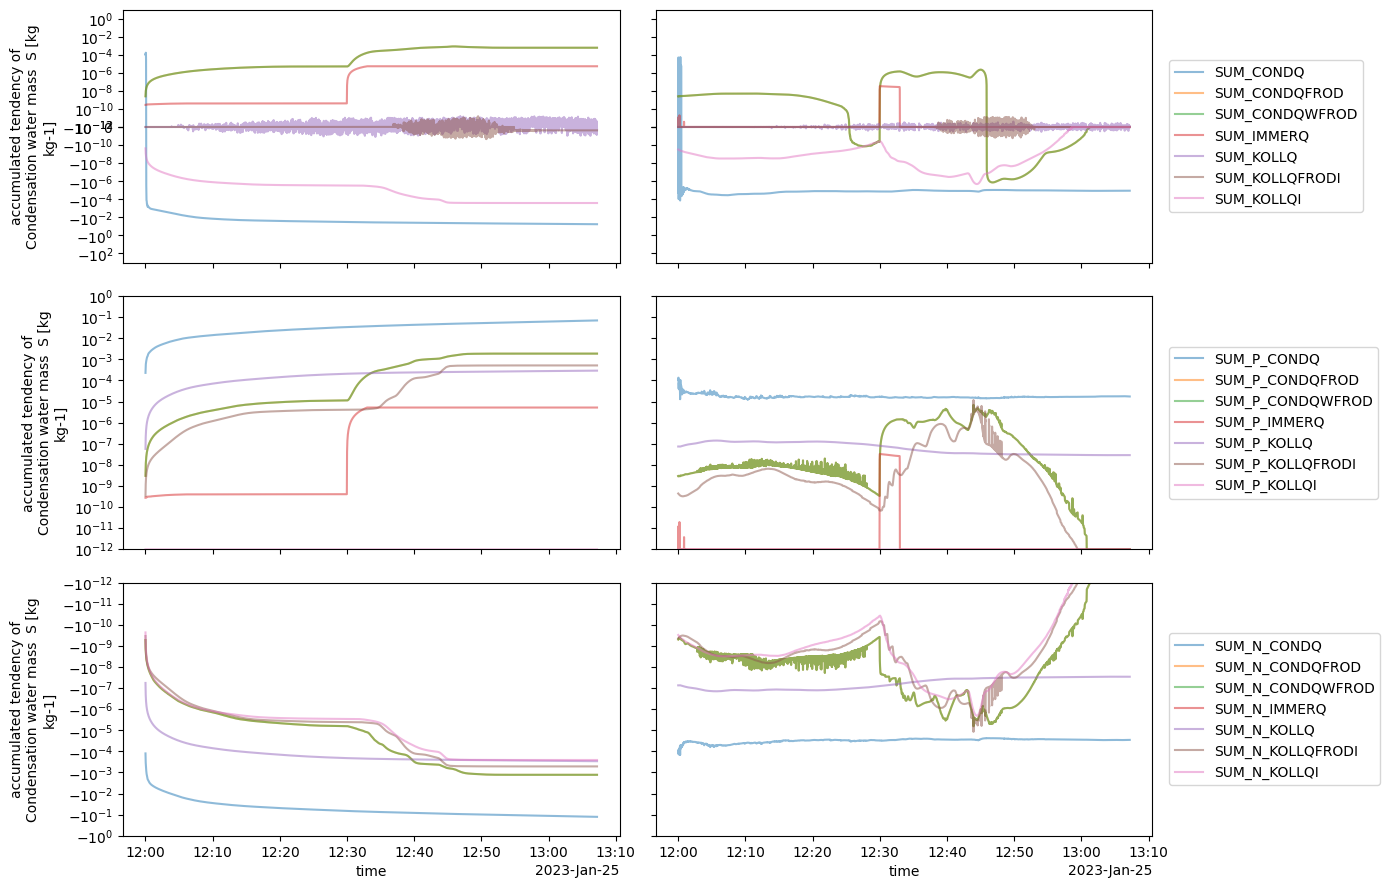

In [177]:
Qfig, Qaxes = plt.subplots(3, 2, figsize=(14, 9),)


for vnt, vpo, vne in zip(net, pos, neg):
    if np.abs(ds_sum_net[vnt]) > 1e-16:
        if 'Q' in vnt[8:11]:
            axes = Qaxes
            ds_tend_net_t[vnt].plot.line(ax=axes[0,0], alpha=0.5)
            ds_tend_pos_t[vpo].plot.line(ax=axes[1,0], alpha=0.5)
            ds_tend_neg_t[vne].plot.line(ax=axes[2,0], alpha=0.5)
            
            ds_flux_net_t[vnt].plot.line(ax=axes[0,1], label=vnt, alpha=0.5)
            ds_flux_pos_t[vpo].plot.line(ax=axes[1,1], label=vpo, alpha=0.5)
            ds_flux_neg_t[vne].plot.line(ax=axes[2,1], label=vne, alpha=0.5)
            
            for i in range(2):
                axes[0,i].set_yscale("symlog", linthresh=1e-12, linscale=0.01)
                axes[0,i].set_ylim(-1e3, 1e1)
                axes[0,i].set_xlabel('')
                axes[0,i].set_xticklabels([])
                axes[1,i].set_yscale("symlog", linthresh=1e-12, linscale=0.01)
                axes[1,i].set_ylim(1e-12, 1e0)
                axes[1,i].set_xlabel('')
                axes[1,i].set_xticklabels([])
                axes[2,i].set_yscale("symlog", linthresh=1e-12, linscale=0.01)
                axes[2,i].set_ylim(-1e0, -1e-12)


for ax in axes:
    ax[1].set_ylabel('')
    ax[1].set_yticklabels([])
    ax[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1)

Qfig.tight_layout()
Qfig.savefig("Qfig.png", dpi=300)

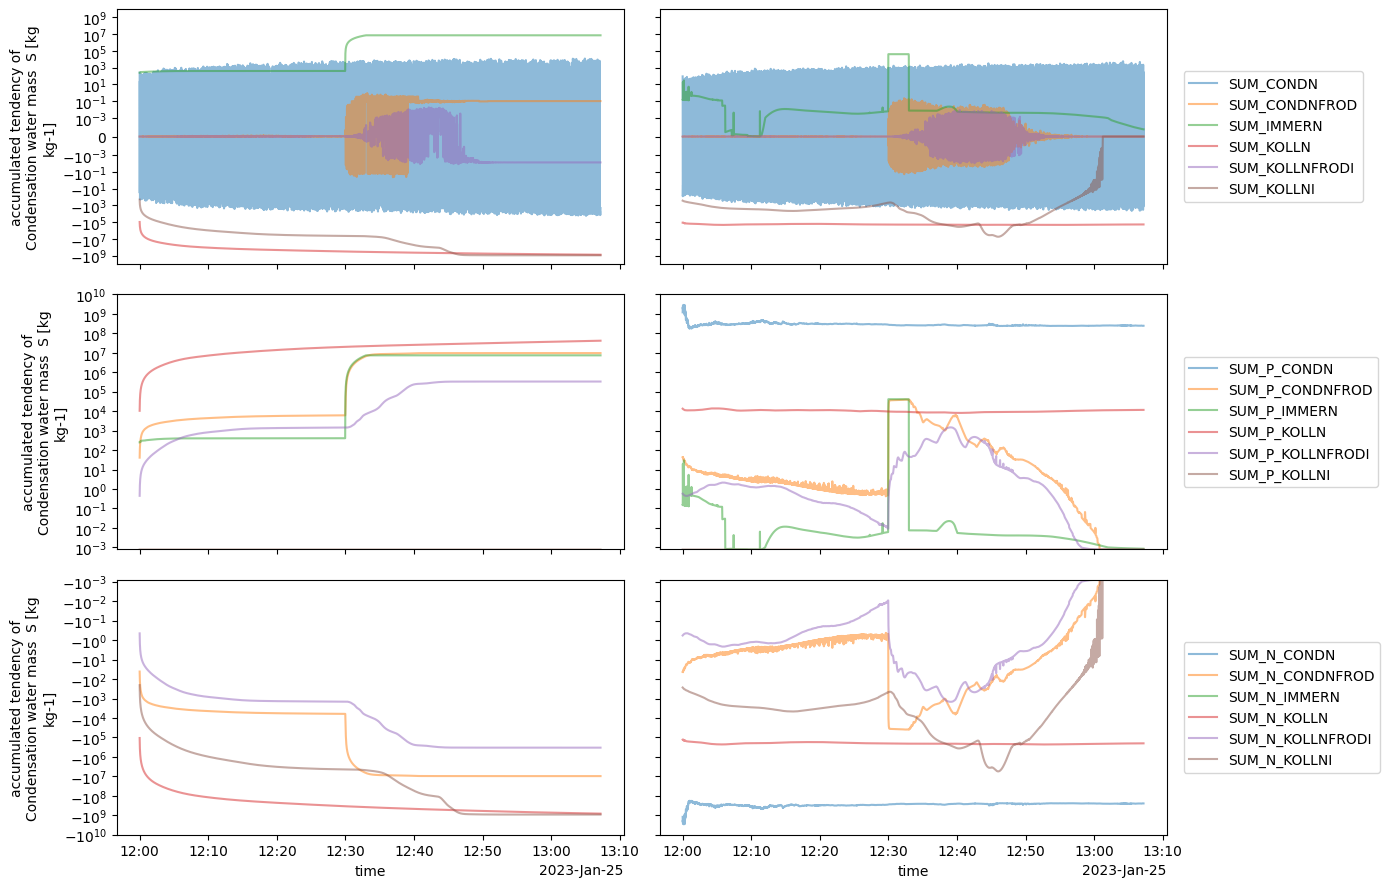

In [178]:

from tkinter import N


Nfig, Naxes = plt.subplots(3, 2, figsize=(14, 9),)

for vnt, vpo, vne in zip(net, pos, neg):
    if np.abs(ds_sum_net[vnt]) > 1e-16:
        if 'N' in vnt[8:11]:
            axes = Naxes
            ds_tend_net_t[vnt].plot.line(ax=axes[0,0], alpha=0.5)
            ds_tend_pos_t[vpo].plot.line(ax=axes[1,0], alpha=0.5)
            ds_tend_neg_t[vne].plot.line(ax=axes[2,0], alpha=0.5)

            ds_flux_net_t[vnt].plot.line(ax=axes[0,1], label=vnt, alpha=0.5)
            ds_flux_pos_t[vpo].plot.line(ax=axes[1,1], label=vpo, alpha=0.5)
            ds_flux_neg_t[vne].plot.line(ax=axes[2,1], label=vne, alpha=0.5)
                        
            for i in range(2):
                axes[0,i].set_yscale("symlog", linthresh=1e-3, linscale=2)
                axes[0,i].set_ylim(-1e10, 1e10)
                axes[0,i].set_xlabel('')
                axes[0,i].set_xticklabels([])
                axes[1,i].set_yscale("symlog", linthresh=1e-3, linscale=0.1)
                axes[1,i].set_ylim(1e-4, 1e10)
                axes[1,i].set_xlabel('')
                axes[1,i].set_xticklabels([])
                axes[2,i].set_yscale("symlog", linthresh=1e-3, linscale=0.1)
                axes[2,i].set_ylim(-1e10, -1e-4)


for ax in Naxes:
    ax[1].set_ylabel('')
    ax[1].set_yticklabels([])
    ax[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1)

Nfig.tight_layout()

Nfig.savefig("Nfig.png", dpi=300)

